# Part 4


Imports

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import equalized_odds_difference

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[inFairness]'


Settings

In [2]:
SEED = 42
MODEL_NAME = "distilbert-base-uncased"
DATA_PATH = r"dataset/jigsaw-unintended-bias-train.csv"
BASE_MODEL_DIR = "saved_models/part1_distilbert"

REWEIGH_MODEL_DIR = "saved_models/part4_reweigh_model"
OVERSAMPLE_MODEL_DIR = "saved_models/part4_oversample_model"

TRAIN_SIZE = 10_000
EVAL_SIZE = 2_000
MAX_LEN = 128

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

os.makedirs("saved_models", exist_ok=True)

Device: cpu


Load threshold from Part 1

In [3]:
with open("saved_models/part1_config.json", "r") as f:
    config = json.load(f)

BEST_THRESHOLD = config["best_threshold"]
print("Baseline threshold:", BEST_THRESHOLD)

Baseline threshold: 0.3


Load dataset and recreate same split

In [4]:
df = pd.read_csv(
    DATA_PATH,
    usecols=[
        "comment_text",
        "toxic",
        "black",
        "white",
        "muslim",
        "jewish",
        "homosexual_gay_or_lesbian"
    ]
)

df = df.dropna(subset=["comment_text", "toxic"]).copy()
df["label"] = (df["toxic"] >= 0.5).astype(int)

sample_total = TRAIN_SIZE + EVAL_SIZE

sampled_df, _ = train_test_split(
    df,
    train_size=sample_total,
    stratify=df["label"],
    random_state=SEED
)

train_df, eval_df = train_test_split(
    sampled_df,
    train_size=TRAIN_SIZE,
    test_size=EVAL_SIZE,
    stratify=sampled_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
eval_df = eval_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Eval shape :", eval_df.shape)

Train shape: (10000, 8)
Eval shape : (2000, 8)


Build train and eval cohorts

In [5]:
train_df["group"] = "other"
train_df.loc[train_df["black"] >= 0.5, "group"] = "high_black"
train_df.loc[(train_df["black"] < 0.1) & (train_df["white"] >= 0.5), "group"] = "reference"

eval_df["group"] = "other"
eval_df.loc[eval_df["black"] >= 0.5, "group"] = "high_black"
eval_df.loc[(eval_df["black"] < 0.1) & (eval_df["white"] >= 0.5), "group"] = "reference"

print(train_df["group"].value_counts())
print(eval_df["group"].value_counts())

group
other         9805
reference      119
high_black      76
Name: count, dtype: int64
group
other         1973
reference       14
high_black      13
Name: count, dtype: int64


Load baseline model and get eval probabilities

In [6]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_DIR)
baseline_model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL_DIR).to(DEVICE)
baseline_model.eval()

def predict_probs(texts, model, tokenizer, batch_size=16):
    probs_all = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        enc = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

        probs_all.extend(probs)

    return np.array(probs_all)

eval_df["baseline_prob"] = predict_probs(
    eval_df["comment_text"].tolist(),
    baseline_model,
    tokenizer
)
eval_df["baseline_pred"] = (eval_df["baseline_prob"] >= BEST_THRESHOLD).astype(int)

eval_df[["comment_text", "label", "group", "baseline_prob", "baseline_pred"]].head()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,comment_text,label,group,baseline_prob,baseline_pred
0,Your point is well taken Danno!\n\nIt's intere...,0,other,0.004654,0
1,"But if the only witness is the victim, what then?",0,other,0.006027,0
2,"Fascinating work, not so much the attack on Br...",0,other,0.005367,0
3,"All taxes, except those that you do not pay, a...",0,other,0.002821,0
4,Sorry to say Mr. Brule it is Obama who has pla...,1,other,0.095400,0


Metric helper functions

In [7]:
def compute_group_metrics(df_group, pred_col="pred"):
    y_true = df_group["label"].values
    y_pred = df_group[pred_col].values

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    ppr = (y_pred == 1).mean() if len(y_pred) > 0 else 0.0

    return {
        "TPR": tpr,
        "FPR": fpr,
        "FNR": fnr,
        "Precision": precision,
        "PositivePredictionRate": ppr
    }

def compute_summary_metrics(df_full, pred_col="pred"):
    overall_f1 = f1_score(df_full["label"], df_full[pred_col], average="macro")

    hb = df_full[df_full["group"] == "high_black"].copy()
    ref = df_full[df_full["group"] == "reference"].copy()

    hb_m = compute_group_metrics(hb, pred_col=pred_col)
    ref_m = compute_group_metrics(ref, pred_col=pred_col)

    spd = hb_m["PositivePredictionRate"] - ref_m["PositivePredictionRate"]
    eod = hb_m["TPR"] - ref_m["TPR"]

    return {
        "Overall F1": overall_f1,
        "High-black FPR": hb_m["FPR"],
        "Reference cohort FPR": ref_m["FPR"],
        "Statistical parity difference": spd,
        "Equal opportunity difference": eod
    }

def add_pred_column(df_in, probs, threshold, col_name="pred"):
    df_out = df_in.copy()
    df_out[col_name] = (probs >= threshold).astype(int)
    return df_out

Baseline row for comparison table

In [8]:
baseline_eval = add_pred_column(
    eval_df.copy(),
    eval_df["baseline_prob"].values,
    BEST_THRESHOLD,
    col_name="pred"
)

baseline_metrics = compute_summary_metrics(baseline_eval, pred_col="pred")
baseline_metrics

{'Overall F1': 0.7882430711751865,
 'High-black FPR': np.float64(0.1111111111111111),
 'Reference cohort FPR': np.float64(0.0),
 'Statistical parity difference': np.float64(0.15384615384615385),
 'Equal opportunity difference': np.float64(0.25)}

Prepare AIF360 reweighing dataset

In [9]:
train_rw = train_df.copy()

train_rw["is_high_black"] = (train_rw["group"] == "high_black").astype(int)
train_rw["is_reference"] = (train_rw["group"] == "reference").astype(int)

# AIF360 works best with one protected attribute
# We'll define protected=1 for privileged reference cohort, 0 otherwise
train_rw["protected_ref"] = train_rw["is_reference"]

rw_df = train_rw[["label", "protected_ref"]].copy()

rw_dataset = BinaryLabelDataset(
    favorable_label=1,
    unfavorable_label=0,
    df=rw_df,
    label_names=["label"],
    protected_attribute_names=["protected_ref"]
)

RW = Reweighing(
    unprivileged_groups=[{"protected_ref": 0}],
    privileged_groups=[{"protected_ref": 1}]
)

rw_transformed = RW.fit_transform(rw_dataset)
sample_weights = rw_transformed.instance_weights

print("Sample weights shape:", sample_weights.shape)
print("First 10 weights:", sample_weights[:10])

Sample weights shape: (10000,)
First 10 weights: [0.99753319 0.99753319 0.99753319 0.99753319 0.99753319 0.99753319
 0.99753319 0.99753319 0.99753319 0.99753319]


Tokenize helper

In [10]:
def tokenize_batch(batch):
    return tokenizer(
        batch["comment_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

Build weighted HF datasets

In [11]:
reweigh_train_df = train_df.copy()
reweigh_train_df["sample_weight"] = sample_weights

reweigh_train_hf = Dataset.from_pandas(
    reweigh_train_df[["comment_text", "label", "sample_weight"]],
    preserve_index=False
)

reweigh_eval_hf = Dataset.from_pandas(
    eval_df[["comment_text", "label"]],
    preserve_index=False
)

reweigh_train_hf = reweigh_train_hf.map(tokenize_batch, batched=True)
reweigh_eval_hf = reweigh_eval_hf.map(tokenize_batch, batched=True)

reweigh_train_hf = reweigh_train_hf.remove_columns(["comment_text"])
reweigh_eval_hf = reweigh_eval_hf.remove_columns(["comment_text"])

reweigh_train_hf.set_format("torch")
reweigh_eval_hf.set_format("torch")

print(reweigh_train_hf)
print(reweigh_eval_hf)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'sample_weight', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10000
})
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})


Weighted trainer class

In [16]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        sample_weight = inputs.pop("sample_weight", None)

        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = torch.nn.CrossEntropyLoss(reduction="none")
        losses = loss_fct(logits, labels)

        if sample_weight is not None:
            sample_weight = sample_weight.float().to(losses.device)
            losses = losses * sample_weight

        loss = losses.mean()

        return (loss, outputs) if return_outputs else loss

Train reweighed model

In [17]:
reweigh_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

reweigh_args = TrainingArguments(
    output_dir=REWEIGH_MODEL_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=SEED,
    remove_unused_columns=False
)

reweigh_trainer = WeightedTrainer(
    model=reweigh_model,
    args=reweigh_args,
    train_dataset=reweigh_train_hf,
    eval_dataset=reweigh_eval_hf
)

print("Training reweighed model...")
reweigh_trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training reweighed model...


Epoch,Training Loss,Validation Loss
1,0.218401,0.191358


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1250, training_loss=0.21956898307800293, metrics={'train_runtime': 1867.8122, 'train_samples_per_second': 5.354, 'train_steps_per_second': 0.669, 'total_flos': 331168496640000.0, 'train_loss': 0.21956898307800293, 'epoch': 1.0})

Evaluate reweighed model

In [18]:
reweigh_model = reweigh_trainer.model.to(DEVICE)
reweigh_model.eval()

eval_df["reweigh_prob"] = predict_probs(
    eval_df["comment_text"].tolist(),
    reweigh_model,
    tokenizer
)
eval_df["reweigh_pred"] = (eval_df["reweigh_prob"] >= BEST_THRESHOLD).astype(int)

reweigh_metrics = compute_summary_metrics(eval_df, pred_col="reweigh_pred")
reweigh_metrics

{'Overall F1': 0.7692168207968613,
 'High-black FPR': np.float64(0.1111111111111111),
 'Reference cohort FPR': np.float64(0.0),
 'Statistical parity difference': np.float64(0.15384615384615385),
 'Equal opportunity difference': np.float64(0.25)}

Threshold optimization with Fairlearn

In [19]:
to_df = eval_df[eval_df["group"].isin(["high_black", "reference"])].copy()

X_scores = to_df[["baseline_prob"]].values
y_true = to_df["label"].values
sensitive = to_df["group"].values

class ScoreEstimator:
    def fit(self, X, y):
        return self

    def predict(self, X):
        return (X[:, 0] >= 0.5).astype(int)

    def predict_proba(self, X):
        probs = X[:, 0]
        return np.vstack([1 - probs, probs]).T

score_estimator = ScoreEstimator()

threshold_optimizer = ThresholdOptimizer(
    estimator=score_estimator,
    constraints="equalized_odds",
    predict_method="predict_proba",
    prefit=True
)

threshold_optimizer.fit(X_scores, y_true, sensitive_features=sensitive)
to_preds = threshold_optimizer.predict(X_scores, sensitive_features=sensitive)

to_df["thresholdopt_pred"] = to_preds.astype(int)

to_metrics = compute_summary_metrics(to_df, pred_col="thresholdopt_pred")
to_metrics

f:\areeba responsible\.venv\lib\site-packages\fairlearn\postprocessing\_threshold_optimizer.py:329: UserWarning: The value of `prefit` is `True`, but `check_is_fitted` raised `NotFittedError` on the base estimator.

If the provided base estimator has been fitted, this could mean that (1) its implementation does not conform to the sklearn estimator API, or (2) the enclosing ThresholdOptimizer has been cloned (for instance by `sklearn.model_selection.cross_validate`).

In case (1), please file an issue with the base estimator developers, but continue to use the enclosing ThresholdOptimizer with `prefit=True`. In case (2), please use `prefit=False`.
  warn(BASE_ESTIMATOR_NOT_FITTED_WARNING.format(type(self).__name__))
f:\areeba responsible\.venv\lib\site-packages\fairlearn\postprocessing\_interpolated_thresholder.py:102: UserWarning: The value of `prefit` is `True`, but `check_is_fitted` raised `NotFittedError` on the base estimator.

If the provided base estimator has been fitted, this c

{'Overall F1': 0.6318181818181818,
 'High-black FPR': np.float64(0.0),
 'Reference cohort FPR': np.float64(0.16666666666666666),
 'Statistical parity difference': np.float64(-0.13736263736263735),
 'Equal opportunity difference': np.float64(-0.25)}

Pareto-style sweep

In [20]:
hb_df = to_df[to_df["group"] == "high_black"].copy()
ref_df = to_df[to_df["group"] == "reference"].copy()

rows = []

for hb_th in np.arange(0.3, 0.71, 0.05):
    for ref_th in np.arange(0.3, 0.71, 0.05):
        temp = to_df.copy()

        temp["pareto_pred"] = 0
        temp.loc[temp["group"] == "high_black", "pareto_pred"] = (
            temp.loc[temp["group"] == "high_black", "baseline_prob"] >= hb_th
        ).astype(int)
        temp.loc[temp["group"] == "reference", "pareto_pred"] = (
            temp.loc[temp["group"] == "reference", "baseline_prob"] >= ref_th
        ).astype(int)

        summary = compute_summary_metrics(temp, pred_col="pareto_pred")

        rows.append({
            "hb_threshold": hb_th,
            "ref_threshold": ref_th,
            "overall_f1": summary["Overall F1"],
            "equal_opportunity_difference": abs(summary["Equal opportunity difference"])
        })

pareto_df = pd.DataFrame(rows)
pareto_df.head()

,hb_threshold,ref_threshold,overall_f1,equal_opportunity_difference
0,0.3,0.30,0.559783,0.25
1,0.3,0.35,0.559783,0.25
2,0.3,0.40,0.559783,0.25
3,0.3,0.45,0.559783,0.25
4,0.3,0.50,0.559783,0.25


Pareto plot

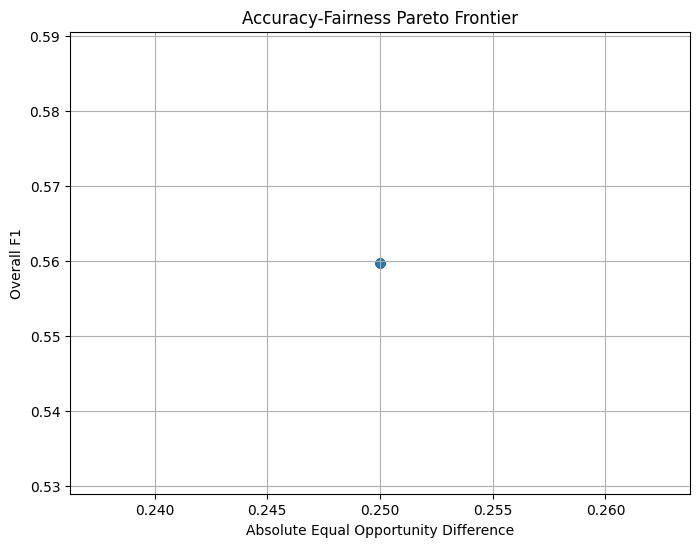

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(
    pareto_df["equal_opportunity_difference"],
    pareto_df["overall_f1"],
    alpha=0.7
)
plt.xlabel("Absolute Equal Opportunity Difference")
plt.ylabel("Overall F1")
plt.title("Accuracy-Fairness Pareto Frontier")
plt.grid(True)
plt.show()

Oversampling setup

In [22]:
high_black_train = train_df[train_df["group"] == "high_black"].copy()

oversampled_train_df = pd.concat(
    [train_df, high_black_train, high_black_train, high_black_train],
    ignore_index=True
)

print("Original train size:", len(train_df))
print("High-black train size:", len(high_black_train))
print("Oversampled train size:", len(oversampled_train_df))

Original train size: 10000
High-black train size: 76
Oversampled train size: 10228


Tokenize oversampled datasets

In [23]:
oversample_train_hf = Dataset.from_pandas(
    oversampled_train_df[["comment_text", "label"]],
    preserve_index=False
)

oversample_eval_hf = Dataset.from_pandas(
    eval_df[["comment_text", "label"]],
    preserve_index=False
)

oversample_train_hf = oversample_train_hf.map(tokenize_batch, batched=True)
oversample_eval_hf = oversample_eval_hf.map(tokenize_batch, batched=True)

oversample_train_hf = oversample_train_hf.remove_columns(["comment_text"])
oversample_eval_hf = oversample_eval_hf.remove_columns(["comment_text"])

oversample_train_hf.set_format("torch")
oversample_eval_hf.set_format("torch")

print(oversample_train_hf)
print(oversample_eval_hf)

Map:   0%|          | 0/10228 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10228
})
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})


Train oversampled model

In [24]:
oversample_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

oversample_args = TrainingArguments(
    output_dir=OVERSAMPLE_MODEL_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=SEED
)

oversample_trainer = Trainer(
    model=oversample_model,
    args=oversample_args,
    train_dataset=oversample_train_hf,
    eval_dataset=oversample_eval_hf
)

print("Training oversampled model...")
oversample_trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training oversampled model...


f:\areeba responsible\.venv\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.232882,0.189248


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1279, training_loss=0.22264565407437584, metrics={'train_runtime': 2216.9186, 'train_samples_per_second': 4.614, 'train_steps_per_second': 0.577, 'total_flos': 338719138363392.0, 'train_loss': 0.22264565407437584, 'epoch': 1.0})

Evaluate oversampled model

In [25]:
oversample_model = oversample_trainer.model.to(DEVICE)
oversample_model.eval()

eval_df["oversample_prob"] = predict_probs(
    eval_df["comment_text"].tolist(),
    oversample_model,
    tokenizer
)
eval_df["oversample_pred"] = (eval_df["oversample_prob"] >= BEST_THRESHOLD).astype(int)

oversample_metrics = compute_summary_metrics(eval_df, pred_col="oversample_pred")
oversample_metrics

{'Overall F1': 0.7826475504289119,
 'High-black FPR': np.float64(0.3333333333333333),
 'Reference cohort FPR': np.float64(0.08333333333333333),
 'Statistical parity difference': np.float64(0.46703296703296704),
 'Equal opportunity difference': np.float64(1.0)}

comparison table

In [26]:
comparison_table = pd.DataFrame([
    {"Technique": "Baseline", **baseline_metrics},
    {"Technique": "Reweighing", **reweigh_metrics},
    {"Technique": "Threshold Optimization", **to_metrics},
    {"Technique": "Oversampling", **oversample_metrics},
])

comparison_table

,Technique,Overall F1,High-black FPR,Reference cohort FPR,Statistical parity difference,Equal opportunity difference
0,Baseline,0.788243,0.111111,0.000000,0.153846,0.25
1,Reweighing,0.769217,0.111111,0.000000,0.153846,0.25
2,Threshold Optimization,0.631818,0.000000,0.166667,-0.137363,-0.25
3,Oversampling,0.782648,0.333333,0.083333,0.467033,1.00


Base rates for incompatibility question

In [27]:
hb_eval = eval_df[eval_df["group"] == "high_black"].copy()
ref_eval = eval_df[eval_df["group"] == "reference"].copy()

hb_base_rate = hb_eval["label"].mean() if len(hb_eval) > 0 else np.nan
ref_base_rate = ref_eval["label"].mean() if len(ref_eval) > 0 else np.nan

print("High-black base rate:", hb_base_rate)
print("Reference base rate :", ref_base_rate)
print("Base rate difference :", hb_base_rate - ref_base_rate)

High-black base rate: 0.3076923076923077
Reference base rate : 0.14285714285714285
Base rate difference : 0.16483516483516486


In [28]:

comparison_table.to_csv("saved_models/part4_comparison_table.csv", index=False)
pareto_df.to_csv("saved_models/part4_pareto_points.csv", index=False)

reweigh_trainer.save_model(REWEIGH_MODEL_DIR)
tokenizer.save_pretrained(REWEIGH_MODEL_DIR)

oversample_trainer.save_model(OVERSAMPLE_MODEL_DIR)
tokenizer.save_pretrained(OVERSAMPLE_MODEL_DIR)

print("Saved:")
print(" - saved_models/part4_comparison_table.csv")
print(" - saved_models/part4_pareto_points.csv")
print(" -", REWEIGH_MODEL_DIR)
print(" -", OVERSAMPLE_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved:
 - saved_models/part4_comparison_table.csv
 - saved_models/part4_pareto_points.csv
 - saved_models/part4_reweigh_model
 - saved_models/part4_oversample_model
